In [25]:
import os
import sys
current_dir = os.path.dirname(os.getcwd())
if not current_dir in sys.path:
    sys.path.append(current_dir)

# ----------------------------------------------------

In [26]:
import math
import torch
import numpy as np
import pandas as pd
import IR_UTE as ute
import phantom as pt
import torchkbnufft as tkbn
import randialSampling as rs
import matplotlib.pyplot as plt

In [27]:
dt = 10 # unite: us
t1_wm =  0.8  
t2_wm = 0.08
t1_myelin = 0.226         
t2_myelin = 300 * 1e-6
df = np.linspace(-500, 500, 200)

img_size = 256
n_readout = 4
t_readout = 0.768 * 1e-3 #s
t_nullout = int(0.55 * 1e6)

TE1 = 8 # us
TE2 = 2.2 * 1e3 # us

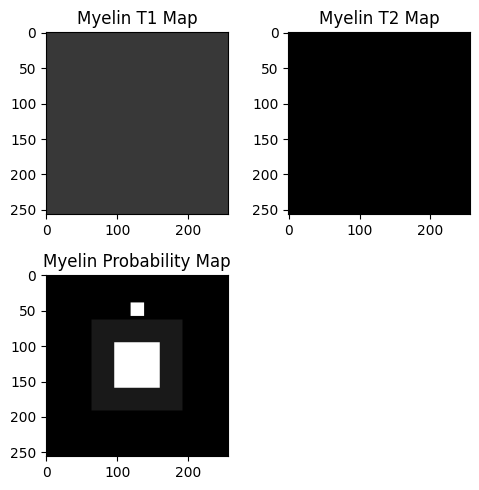

In [28]:
inner_myelin = 1
mixed_myelin = 0.1
outer_myelin = 0

myelin = pt.VirtualPhantom(img_size)
t1_map_myelin, t2_map_myelin, prob_map_myelin = myelin.create_maps(t1_myelin, t2_myelin, inner_myelin, mixed_myelin, outer_myelin, upper_sqaure=True)
myelin.phantom_display('Myelin')

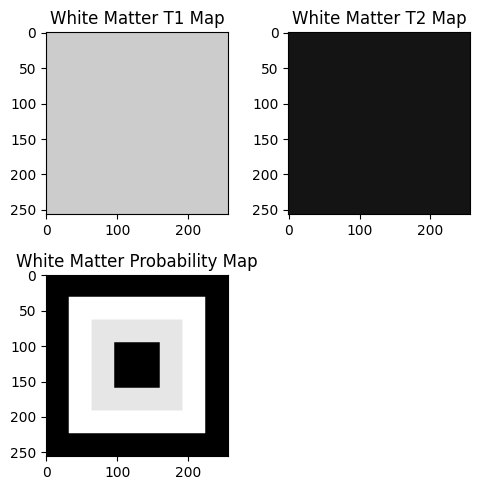

In [29]:
inner_wm = 0
mixed_wm = 0.9
outer_wm = 1

wm = pt.VirtualPhantom(img_size)
t1_map_wm, t2_map_wm, prob_map_wm = wm.create_maps(t1_wm, t2_wm, inner_wm, mixed_wm, outer_wm, upper_sqaure = True)
wm.phantom_display('White Matter')

In [ ]:
class SNRCalc():
    def __init__(self, dt, df, t1_myelin, t2_myelin, t1_wm, t2_wm, img_size = 256, n_readout = 9, flip_angle = math.pi/2):
        self.dt = dt
        self.df = df
        self.t1_myelin = t1_myelin
        self.t2_myelin = t2_myelin
        self.t1_wm = t1_wm
        self.t2_wm = t2_wm
        self.img_size = img_size
        self.n_readout = n_readout
        self.flip_angle = flip_angle
        pass

    def combined_kdata_ktraj(self, t_readout, prob_map_myelin, prob_map_wm):
        print('white matter')
        wm = ute.IR_UTE(self.dt, self.df, self.t1_wm, self.t2_wm)
        self.TR = wm.TR
        _ = wm.inversion_recovery()
        t_nullout = wm.calculate_nulling_point()
        _, _, mag_readout_start_wm, _ = wm.transverse_excitation(self.n_readout, t_readout, t_nullout, self.flip_angle, TE1)

        print()
        print('myelin')
        myelin = ute.IR_UTE(self.dt, self.df, self.t1_myelin, self.t2_myelin)
        _ = myelin.inversion_recovery()
        _, _, mag_readout_start_myelin, _ = myelin.transverse_excitation(self.n_readout, t_readout, t_nullout, self.flip_angle, TE1)


        radial_sampling = rs.RadialSampling(self.img_size)
        self.nspokes = radial_sampling.nspokes
        kdata_t_myelin, ktraj_total = radial_sampling.get_kdata_ktraj(self.df, mag_readout_start_myelin, prob_map_myelin, self.n_readout, self.t2_myelin, t_readout)
        kdata_t_wm, _ = radial_sampling.get_kdata_ktraj(self.df, mag_readout_start_wm, prob_map_wm, self.n_readout, self.t2_wm, t_readout)
        
        kdata_total = kdata_t_myelin + kdata_t_wm
        self.radial_sampling = radial_sampling


        print("flip_angle:", self.flip_angle)
        print("mag_readout_start_myelin:", mag_readout_start_myelin)
        print("mag_readout_start_wm:", mag_readout_start_wm)
        return kdata_total, ktraj_total
    
    def SNR_CNR_calculation(self, kdata_total, ktraj_total, prob_map_myelin, prob_map_wm, blur=False):
        radial_sampling = rs.RadialSampling(self.img_size)
        if blur:
            # method 1: no density compensation (blurry image)
            image = radial_sampling.adjnufft_ob(kdata_total, ktraj_total)
        else:
            # method 2: use density compensation
            dcomp = tkbn.calc_density_compensation_function(ktraj=ktraj_total, im_size=(self.img_size, self.img_size))
            image = radial_sampling.adjnufft_ob(kdata_total * dcomp, ktraj_total)

    
        image_numpy = np.squeeze(image.cpu().numpy())
        print(image_numpy.shape)
        image_abs = np.abs(image_numpy) 

        noise_std = np.std(image_abs[(prob_map_myelin == 0) & (prob_map_wm == 0)])
        print(image_abs[(prob_map_myelin == 0) & (prob_map_wm == 0)])
        myelin_mean = np.mean(image_abs[prob_map_myelin == 1])
        wm_mean = np.mean(image_abs[prob_map_wm == 1])

        print('noise_std:', noise_std)
        print('noise mean:', np.mean(image_abs[(prob_map_myelin == 0) & (prob_map_wm == 0)]))
        print('myelin_mean:', myelin_mean)
        print('wm_mean:', wm_mean)
        
        snr_myelin = 0.66 * myelin_mean / noise_std
        snr_wm = 0.66 * wm_mean / noise_std
        cnr = 0.66 * abs(myelin_mean - wm_mean) / noise_std
        print("SNR_myelin:", snr_myelin)
        print("SNR_wm:", snr_wm)
        print('SNR Noise:', 0.66 * np.mean(image_abs[(prob_map_myelin == 0) & (prob_map_wm == 0)])/noise_std)
        return  snr_myelin, snr_wm, cnr
    
    def total_acquisation_time_calc(self, TR):
        """
        TR: repetition time in ms
        """
        radial_sampling = rs.RadialSampling(self.img_size)
        nspokes = radial_sampling.nspokes

        n_TR = np.ceil(nspokes / self.n_readout)
        total_TA = n_TR * TR
        return total_TA




## (1) Plot flip angle vs SNR across different n_readout

In [31]:
import math

import matplotlib.pyplot as plt

def readout_angle_pairs_display(n_readout_list, angles_deg_list):
    flip_angle_list = [angle * torch.pi / 180 for angle in angles_deg_list]

    n_plots = len(n_readout_list)
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4))

    if n_plots == 1:
        axes = [axes]

    results = []
    for ax, n_readout in zip(axes, n_readout_list):
        snr_myelin_list, snr_wm_list, cnr_list, total_TA_list = [], [], [], []
        
        for index, flip_angle in enumerate(flip_angle_list):
            combined = SNRCalc(
                dt, df,
                t1_myelin, t2_myelin,
                t1_wm, t2_wm,
                img_size=img_size,
                n_readout=n_readout,
                flip_angle=flip_angle
            )
            
            kdata_total, ktraj_total = combined.combined_kdata_ktraj(
                t_readout, prob_map_myelin, prob_map_wm
            )

            snr_myelin, snr_wm, cnr = combined.SNR_CNR_calculation(
                kdata_total, ktraj_total, prob_map_myelin, prob_map_wm
            )
            TR = combined.TR
            total_TA = combined.total_acquisation_time_calc(TR) * 1e-6
            
            snr_myelin_list.append(snr_myelin)
            snr_wm_list.append(snr_wm)
            cnr_list.append(cnr)
            total_TA_list.append(total_TA)

            results.append({
            "n_readout": n_readout,
            "flip_angle": angles_deg_list[index],
            "snr_myelin": snr_myelin,
            "snr_wm": snr_wm,
            "cnr": cnr,
            "TA (min)": np.round(total_TA/60,2) ,
            "efficiency": cnr / math.sqrt(total_TA)})


        ax.plot(angles_deg_list, snr_myelin_list, label='Myelin SNR')
        ax.plot(angles_deg_list, snr_wm_list, label='WM SNR')
        ax.set_title(f'n_readout = {n_readout}')
        ax.set_ylim([0,50])
        ax.set_ylabel('SNR') 
        ax.set_xlabel('Flip angle (deg)')
        ax.legend()
        ax.grid(True)

    # axes[0].set_ylabel('SNR')


    plt.tight_layout()
    plt.show()

    table = pd.DataFrame(results)
    #table.to_csv("cnr_efficiency_table.csv")


white matter
t_readout_end_index: 420
write_start: 0
initial_mag: [-7.36281197e-06  1.55293615e-05 -8.47083881e-07]
Angle=0.17453292519943295, M after 1 step: [-7.36434288e-06  1.55295988e-05  1.16483960e-05]
write_start: 420
initial_mag: [0.         0.         0.00522876]
Angle=0.17453292519943295, M after 1 step: [0.00000000e+00 1.50290347e-06 5.24119392e-03]
write_start: 840
initial_mag: [0.         0.         0.01035019]
Angle=0.17453292519943295, M after 1 step: [0.00000000e+00 2.97144730e-06 1.03625628e-02]
write_start: 1260
initial_mag: [0.       0.       0.015363]
Angle=0.17453292519943295, M after 1 step: [0.00000000e+00 4.40884339e-06 1.53753077e-02]
write_start: 1680
initial_mag: [0.         0.         0.02026949]
Angle=0.17453292519943295, M after 1 step: [0.00000000e+00 5.81575238e-06 2.02817325e-02]
write_start: 2100
initial_mag: [0.         0.         0.02507191]
Angle=0.17453292519943295, M after 1 step: [0.00000000e+00 7.19282091e-06 2.50840922e-02]
write_start: 2520
i

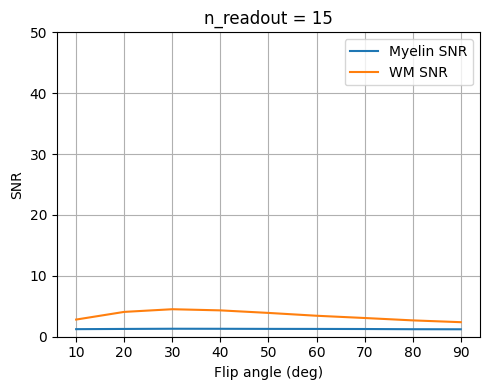

In [32]:
angles_deg_list = [10,20,30,40,50,60,70,80,90]
n_readout_list = [15] 
# n_readout_list = [20, 25, 30, 40] 
#TR = 1000 # ms --> Change TR in IR_UTE
readout_angle_pairs_display(n_readout_list, angles_deg_list)

## (2) Visualize CNR efficiency (create table and heatmaps)

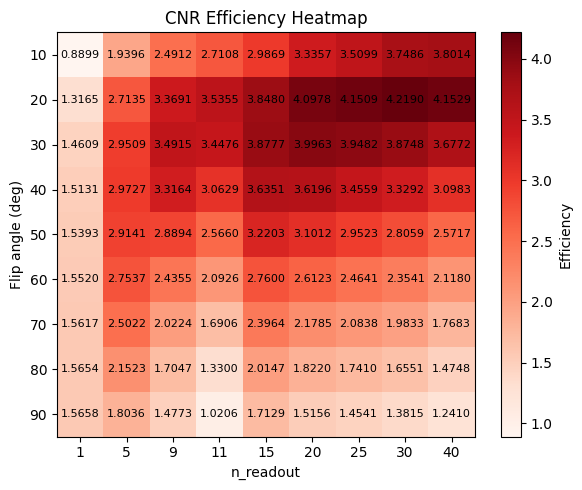

In [ ]:
import pandas as pd

df = pd.read_csv("cnr_efficiency_table.csv")

# (1) Save pivot efficiency table
pivot_eff = df.pivot(
    index="flip_angle",   
    columns="n_readout",      
    values="efficiency"       
)
pivot_eff = pivot_eff.sort_index().sort_index(axis=1)
pivot_eff.to_csv("pivot_efficiency.csv")


# (2) Plot CNR efficiency across different n_readout and flip angles
plt.figure(figsize=(6, 5))
im = plt.imshow(pivot_eff, aspect='auto', cmap='Reds')
plt.colorbar(im, label='Efficiency')
plt.xticks(range(len(pivot_eff.columns)), pivot_eff.columns)
plt.yticks(range(len(pivot_eff.index)), pivot_eff.index)

# Add values inside cells 
for i in range(len(pivot_eff.index)):
    for j in range(len(pivot_eff.columns)):
        val = pivot_eff.iloc[i, j]
        plt.text(j, i, f"{val:.4f}", ha='center', va='center', fontsize=8)

plt.xlabel('n_readout')
plt.ylabel('Flip angle (deg)')
plt.title('CNR Efficiency Heatmap')

plt.tight_layout()
plt.show()

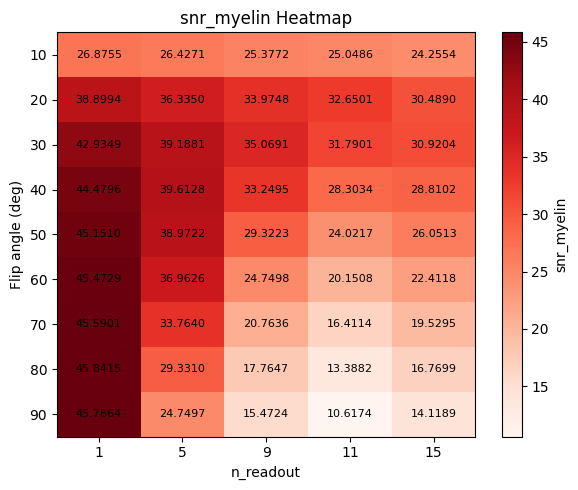

In [ ]:
import pandas as pd

df = pd.read_csv("cnr_efficiency_table.csv")

# (1) Save pivot efficiency table
pivot_eff = df.pivot(
    index="flip_angle",   
    columns="n_readout",      
    values="snr_myelin"       
)
pivot_eff = pivot_eff.sort_index().sort_index(axis=1)
pivot_eff.to_csv("pivot_efficiency.csv")


# (2) Plot CNR efficiency across different n_readout and flip angles
plt.figure(figsize=(6, 5))
im = plt.imshow(pivot_eff, aspect='auto', cmap='Reds')
plt.colorbar(im, label='snr_myelin')
plt.xticks(range(len(pivot_eff.columns)), pivot_eff.columns)
plt.yticks(range(len(pivot_eff.index)), pivot_eff.index)

# Add values inside cells 
for i in range(len(pivot_eff.index)):
    for j in range(len(pivot_eff.columns)):
        val = pivot_eff.iloc[i, j]
        plt.text(j, i, f"{val:.4f}", ha='center', va='center', fontsize=8)

plt.xlabel('n_readout')
plt.ylabel('Flip angle (deg)')
plt.title('snr_myelin Heatmap')

plt.tight_layout()
plt.show()